# GCN vs. Boosted Forest baseline

Compares the GCN surrogate against the Boosted Forest baseline (see `qol_surrogate.baseline` - same data, same target definition, same train/val/test split, graph removed entirely) on the exact same held-out test scenarios.

Everything here is TAZ-resolution and computed live in this notebook - no hex-resolution data needed, so it's fast for both models (unlike `notebooks/evaluate_hex.ipynb`, which needs the heavy hex-level computation from `scripts/evaluate.py` / `scripts/evaluate_baseline.py`).

Note: the baseline's `model.pkl` is large (~12GB - it's 21 channels x 277 TAZs = 5817 independent boosted-tree ensembles), so loading it takes a bit.

In [11]:
import glob
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch_geometric.loader import DataLoader

from qol_surrogate.baseline import evaluate_baseline, evaluate_baseline_per_taz, flatten_x
from qol_surrogate.data import (
    DRY_BASELINE_DIR, DRY_BASELINE_DIR_NO_19, TAZ_PARQUET_DIR, TAZ_PARQUET_DIR_NO_19, TRANSPORT_MODES, ZONES_FILE,
    build_data_list, build_taz_geometries, build_taz_to_idx, create_edge_index, create_polygon_metrics,
    get_taz_ids, load_dataset_tensors, load_hexes,
)
from qol_surrogate.evaluate import evaluate, evaluate_per_taz
from qol_surrogate.model import GCNResNet

In [12]:
MODELS_DIR = "../models"
BASELINE_MODELS_DIR = "../models/baseline"

# picks the most recently trained run of each - point these at a specific folder instead to load an older run
gcn_run_dir = sorted(d for d in glob.glob(os.path.join(MODELS_DIR, "gcn_resnet_*")) if os.path.isdir(d))[-1]
baseline_run_dir = sorted(d for d in glob.glob(os.path.join(BASELINE_MODELS_DIR, "gbm_*")) if os.path.isdir(d))[-1]

print(f"GCN run:      {gcn_run_dir}")
print(f"Baseline run: {baseline_run_dir}")

GCN run:      ../models/gcn_resnet_20260811_154832
Baseline run: ../models/baseline/gbm_20260812_224534


## Load both models and their shared test set

Both runs used `include_file_19=False` and the same (deterministic, fixed `random_state`) `split_dataset()` call, so they share the exact same held-out `idx_test` scenarios - the comparison below is apples-to-apples.

In [13]:
checkpoint = torch.load(os.path.join(gcn_run_dir, "model.pt"), weights_only=False)
hp = checkpoint["hyperparameters"]
gcn_idx_test = checkpoint["idx_test"]
gcn_include_19 = checkpoint.get("include_file_19", True)
print(f"GCN include_file_19={gcn_include_19}")

# placeholder buffers - load_state_dict overwrites them with the real saved values below
model = GCNResNet(
    in_channels=hp["in_channels"], hidden_channels=hp["hidden_channels"],
    out_channels=hp["out_channels"], n_layers=hp["n_layers"], dropout_rate=hp["dropout_rate"],
    x_mean=torch.zeros(hp["in_channels"]), x_std=torch.ones(hp["in_channels"]),
    y_mean=torch.zeros(hp["out_channels"]), y_std=torch.ones(hp["out_channels"]),
)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

hexes = load_hexes(ZONES_FILE)
taz_ids = get_taz_ids(hexes)
taz_to_idx = build_taz_to_idx(taz_ids)
tazes = build_taz_geometries(hexes)
edge_index, edge_weight = create_edge_index(tazes, taz_to_idx)
area, perimeter = create_polygon_metrics(tazes, taz_ids)

taz_parquet_dir = TAZ_PARQUET_DIR if gcn_include_19 else TAZ_PARQUET_DIR_NO_19
dry_baseline_dir = DRY_BASELINE_DIR if gcn_include_19 else DRY_BASELINE_DIR_NO_19
x, y = load_dataset_tensors(area, perimeter, taz_parquet_dir=taz_parquet_dir, dry_baseline_dir=dry_baseline_dir)

x_test_norm = (x[gcn_idx_test] - model.x_mean) / model.x_std
y_test_norm = (y[gcn_idx_test] - model.y_mean) / model.y_std

test_data = build_data_list(x_test_norm, y_test_norm, edge_index, edge_weight)
gcn_test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

GCN include_file_19=False


In [14]:
print("Loading the Boosted Forest baseline (model.pkl is ~12GB - this can take a minute)...")
with open(os.path.join(baseline_run_dir, "model.pkl"), "rb") as f:
    baseline_checkpoint = pickle.load(f)

baseline_models = baseline_checkpoint["models"]
baseline_idx_test = baseline_checkpoint["idx_test"]
baseline_include_19 = baseline_checkpoint["include_file_19"]
print(f"Baseline include_file_19={baseline_include_19}")

assert baseline_include_19 == gcn_include_19 and list(baseline_idx_test) == list(gcn_idx_test), (
    "GCN and baseline runs don't share the same test scenarios - not directly comparable. "
    "This should only happen if the two runs used different include_file_19 settings."
)

# raw (un-normalized) x/y for exactly the shared test scenarios - the baseline trains directly on
# raw deviation units, no normalization needed
x_test_flat = flatten_x(x[gcn_idx_test])
y_test = y[gcn_idx_test]

Loading the Boosted Forest baseline (model.pkl is ~12GB - this can take a minute)...


KeyboardInterrupt: 

## Pooled TAZ-level accuracy (all 277 zones combined)

Both deviation (what each model is actually trained to predict) and absolute (deviation + dry baseline).

In [ ]:
gcn_metrics = evaluate(model, gcn_test_loader, dry_baseline_dir=dry_baseline_dir)
baseline_metrics = evaluate_baseline(baseline_models, x_test_flat, y_test, dry_baseline_dir=dry_baseline_dir)

pooled = pd.DataFrame({
    "gcn_deviation": gcn_metrics["deviation"]["overall"],
    "baseline_deviation": baseline_metrics["deviation"]["overall"],
    "gcn_absolute": gcn_metrics["absolute"]["overall"],
    "baseline_absolute": baseline_metrics["absolute"]["overall"],
})
pooled

,gcn_deviation,baseline_deviation,gcn_absolute,baseline_absolute
r2,0.997375,0.996978,0.996831,0.996353
mae,5.694958,6.295327,5.694957,6.295327
c_index,0.979110,0.979273,0.985749,0.986638
wape,0.037648,0.041617,0.030869,0.034124


In [25]:
# shared style for every chart below - color always means the same model across every panel
METRICS = ["r2", "wape", "c_index"]
METRIC_LABELS = {"r2": "R²", "wape": "WAPE", "c_index": "C-index"}
METRICS_WITH_MAX_1 = {"r2", "c_index"}  # WAPE's ideal is 0, not 1 - no reference line for it

COLOR_GCN = "#55A868"       # green - same as "TAZ" in evaluate_hex.ipynb
COLOR_BASELINE = "#A98CC8"  # pastel purple
INK_MUTED = "#898781"
INK_SECONDARY = "#52514e"
GRID_COLOR = "#e1e0d9"

BOX_WIDTH = 0.32
WHISKERS = (5, 95)  # percentile whiskers instead of the 1.5x-IQR rule - a few outliers otherwise
                     # blow up the y axis; nothing beyond the 95th percentile is plotted at all


def per_mode_values(per_channel_dict, mode, metric):
    """The metric's raw per-channel values for one mode (7 POI categories) -
    unlike a mean, this keeps the spread visible in a boxplot."""
    return [m[metric] for col, m in per_channel_dict.items()
            if col.startswith(f"cumulative_accessibility_{mode}_")]


def style_boxplot(bp, color):
    for box in bp["boxes"]:
        box.set_facecolor(color)
        box.set_edgecolor(color)
        box.set_alpha(0.55)
        box.set_linewidth(1.2)
    for element in ("whiskers", "caps"):
        for line in bp[element]:
            line.set_color(INK_MUTED)
            line.set_linewidth(1.0)
    for median in bp["medians"]:
        median.set_color(INK_SECONDARY)
        median.set_linewidth(1.4)


def boxplot_legend(ax_or_fig, **kwargs):
    handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor=COLOR_GCN, alpha=0.55, edgecolor=COLOR_GCN, linewidth=1.2),
        plt.Rectangle((0, 0), 1, 1, facecolor=COLOR_BASELINE, alpha=0.55, edgecolor=COLOR_BASELINE, linewidth=1.2),
    ]
    ax_or_fig.legend(handles, ["GCN", "Boosted Forest"], frameon=False, **kwargs)

## City-wide accuracy, by mode

Same pooling as `evaluate_hex.ipynb`'s summary chart: R², WAPE, and C-index computed once across **all 277 zones combined** - not per zone. Each box is the distribution across the 7 POI categories within a mode (so 7 points per box), pooled city-wide - the same boxplot style as the per-TAZ section below, just showing spread across POI categories at city-wide resolution instead of spread across zones.

The two sections intentionally don't match - pooling across zones scores the model against the much larger *between-zone* variation, so it's a harder number than the per-zone one below. Use this chart when the discussion should stay at the city-wide level.

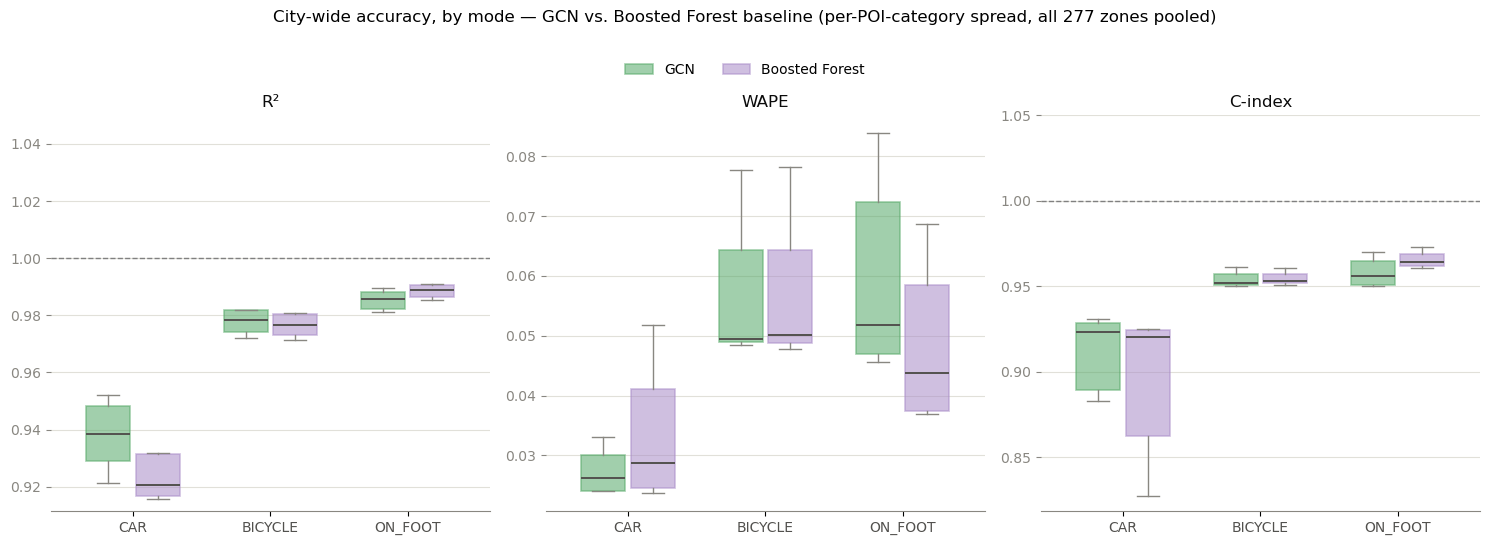

In [26]:
fig, axes = plt.subplots(1, len(METRICS), figsize=(15, 5))
x_pos = np.arange(len(TRANSPORT_MODES))

for ax, metric in zip(axes, METRICS):
    gcn_data = [per_mode_values(gcn_metrics["absolute"]["per_channel"], mode, metric) for mode in TRANSPORT_MODES]
    baseline_data = [per_mode_values(baseline_metrics["absolute"]["per_channel"], mode, metric) for mode in TRANSPORT_MODES]

    ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

    bp_gcn = ax.boxplot(gcn_data, positions=x_pos - BOX_WIDTH / 2 - 0.02, widths=BOX_WIDTH, patch_artist=True,
                         whis=WHISKERS, showfliers=False, zorder=2)
    bp_baseline = ax.boxplot(baseline_data, positions=x_pos + BOX_WIDTH / 2 + 0.02, widths=BOX_WIDTH, patch_artist=True,
                              whis=WHISKERS, showfliers=False, zorder=2)
    style_boxplot(bp_gcn, COLOR_GCN)
    style_boxplot(bp_baseline, COLOR_BASELINE)

    if metric in METRICS_WITH_MAX_1:
        ax.axhline(1.0, color="gray", linewidth=1, linestyle="--", zorder=1)
        ymin, ymax = ax.get_ylim()
        ax.set_ylim(ymin, max(ymax, 1.05))

    ax.set_xlim(-0.6, len(TRANSPORT_MODES) - 0.4)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(TRANSPORT_MODES, color=INK_SECONDARY)
    ax.set_title(METRIC_LABELS[metric], color="#0b0b0b")
    ax.tick_params(axis="y", colors=INK_MUTED)
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(INK_MUTED)

boxplot_legend(fig, loc="upper center", bbox_to_anchor=(0.5, 1.0), ncol=2)
fig.suptitle("City-wide accuracy, by mode — GCN vs. Boosted Forest baseline (per-POI-category spread, all 277 zones pooled)", y=1.08)
fig.tight_layout()
plt.show()

## Per-TAZ accuracy, by mode

For each of the three metrics (R², WAPE, C-index), the per-TAZ distribution across all 277 zones (absolute accessibility, pooled over the 7 POI categories and every test scenario within each zone) - GCN vs. Boosted Forest side by side, grouped by transport mode.

In [ ]:
per_taz_gcn = evaluate_per_taz(model, gcn_test_loader, taz_ids, dry_baseline_dir=dry_baseline_dir)
per_taz_baseline = evaluate_baseline_per_taz(baseline_models, x_test_flat, y_test, taz_ids, dry_baseline_dir=dry_baseline_dir)
per_taz_gcn["r2"].describe()

,CAR,BICYCLE,ON_FOOT
count,277.000000,277.000000,277.000000
mean,0.988393,0.956151,0.970697
std,0.031335,0.085786,0.043744
min,0.739597,0.415495,0.548459
25%,0.994455,0.961888,0.968119
50%,0.997924,0.986068,0.982496
75%,0.998963,0.993307,0.989741
max,0.999680,0.998331,0.996797


NameError: name 'style_boxplot' is not defined

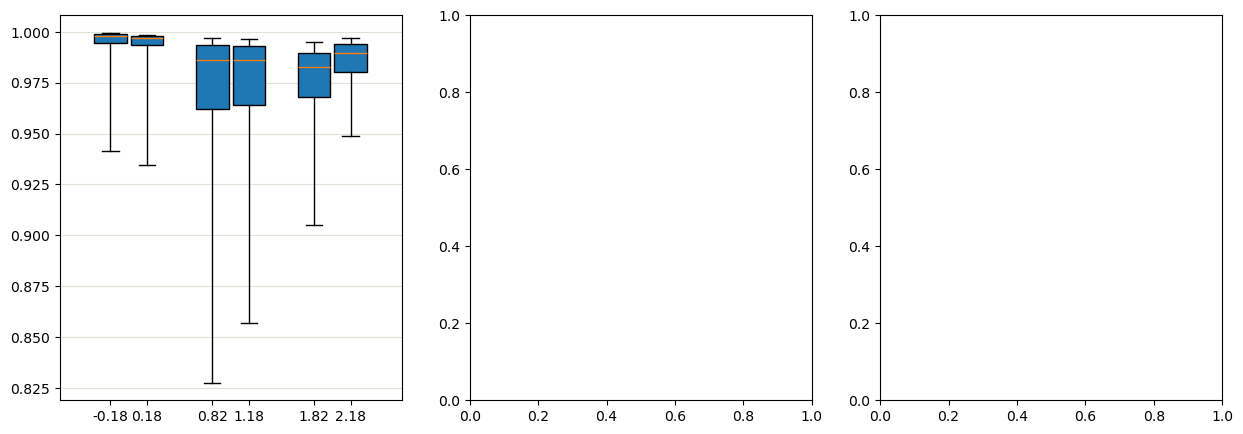

In [23]:
fig, axes = plt.subplots(1, len(METRICS), figsize=(15, 5))
x_pos = np.arange(len(TRANSPORT_MODES))

for ax, metric in zip(axes, METRICS):
    gcn_data = [per_taz_gcn[metric][mode].dropna().to_numpy() for mode in TRANSPORT_MODES]
    baseline_data = [per_taz_baseline[metric][mode].dropna().to_numpy() for mode in TRANSPORT_MODES]

    ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

    bp_gcn = ax.boxplot(gcn_data, positions=x_pos - BOX_WIDTH / 2 - 0.02, widths=BOX_WIDTH, patch_artist=True,
                         whis=WHISKERS, showfliers=False, zorder=2)
    bp_baseline = ax.boxplot(baseline_data, positions=x_pos + BOX_WIDTH / 2 + 0.02, widths=BOX_WIDTH, patch_artist=True,
                              whis=WHISKERS, showfliers=False, zorder=2)
    style_boxplot(bp_gcn, COLOR_GCN)
    style_boxplot(bp_baseline, COLOR_BASELINE)

    if metric in METRICS_WITH_MAX_1:
        ax.axhline(1.0, color="gray", linewidth=1, linestyle="--", zorder=1)
        ymin, ymax = ax.get_ylim()
        ax.set_ylim(ymin, max(ymax, 1.05))

    ax.set_xlim(-0.6, len(TRANSPORT_MODES) - 0.4)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(TRANSPORT_MODES, color=INK_SECONDARY)
    ax.set_title(METRIC_LABELS[metric], color="#0b0b0b")
    ax.tick_params(axis="y", colors=INK_MUTED)
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(INK_MUTED)

boxplot_legend(fig, loc="upper center", bbox_to_anchor=(0.5, 1.0), ncol=2)
fig.suptitle("Per-TAZ accuracy, by mode — GCN vs. Boosted Forest baseline (n=277 TAZs, whiskers = 5th/95th percentile)", y=1.08)
fig.tight_layout()
plt.show()

## Inference latency: raw input to TAZ-resolution prediction

Single-scenario (batch size 1) latency for both models, on the *same* scenario, from raw water-depth input to absolute accessibility at TAZ resolution (deviation + dry baseline) - matches how the RL loop would call either model. Fixed, precomputable infrastructure (the GCN's graph, the dry baseline) is excluded for both, same reasoning as the latency cell in `evaluate_hex.ipynb`.

The GCN is one shared forward pass over all 277 TAZs at once. The Boosted Forest is architecturally very different here: `evaluate_baseline_per_taz`'s design point (see `qol_surrogate.baseline`) means a single scenario triggers 21 separate `MultiOutputRegressor.predict()` calls, each internally looping over its own 277 independent per-TAZ tree ensembles - 5817 individual model calls per scenario. Expect this to show up directly in the timing, so the baseline gets far fewer repeats.

In [ ]:
import time

from qol_surrogate.baseline import predict as baseline_predict
from qol_surrogate.evaluate import _load_taz_dry_baseline

y_dry_taz = _load_taz_dry_baseline(dry_baseline_dir)[0]  # [277, 21] - fixed reference, precomputed once
x_raw_sample = x[gcn_idx_test[0]]  # one scenario's raw input, [277, 5] - same scenario for both models

# --- GCN: normalize -> forward pass -> denormalize -> add dry baseline ---
def gcn_pipeline():
    x_norm = (x_raw_sample - model.x_mean) / model.x_std
    out = model(x_norm, edge_index, edge_weight)
    out_deviation = out * model.y_std + model.y_mean
    return out_deviation + y_dry_taz


n_warmup, n_repeats = 10, 200
with torch.no_grad():
    for _ in range(n_warmup):
        gcn_pipeline()
    gcn_times = []
    for _ in range(n_repeats):
        t0 = time.perf_counter()
        gcn_pipeline()
        gcn_times.append(time.perf_counter() - t0)
gcn_times = np.array(gcn_times) * 1000  # ms

# --- Boosted Forest: flatten -> predict (21 x 277 independent tree ensembles) -> add dry baseline ---
x_raw_flat = x_raw_sample.reshape(1, -1).numpy()


def baseline_pipeline():
    preds = baseline_predict(baseline_models, x_raw_flat)  # [1, 277, 21]
    return torch.from_numpy(preds[0]).float() + y_dry_taz


n_warmup_baseline, n_repeats_baseline = 2, 20  # far fewer - 5817 individual model calls per scenario is slow
for _ in range(n_warmup_baseline):
    baseline_pipeline()
baseline_times = []
for _ in range(n_repeats_baseline):
    t0 = time.perf_counter()
    baseline_pipeline()
    baseline_times.append(time.perf_counter() - t0)
baseline_times = np.array(baseline_times) * 1000  # ms

print(f"GCN            (n={n_repeats}):  mean {gcn_times.mean():.3f} ms, median {np.median(gcn_times):.3f} ms, "
      f"std {gcn_times.std():.3f} ms")
print(f"Boosted Forest (n={n_repeats_baseline}):   mean {baseline_times.mean():.3f} ms, median {np.median(baseline_times):.3f} ms, "
      f"std {baseline_times.std():.3f} ms")
print(f"Boosted Forest is {baseline_times.mean() / gcn_times.mean():.1f}x slower than the GCN, per scenario")

In [ ]:
fig, ax = plt.subplots(figsize=(7, 3))

labels = ["GCN", "Boosted Forest"]
means = [gcn_times.mean(), baseline_times.mean()]
colors = [COLOR_GCN, COLOR_BASELINE]

bars = ax.barh(labels, means, color=colors, alpha=0.7, edgecolor=colors, linewidth=1.2, height=0.5, zorder=2)
ax.set_xscale("log")
ax.set_xlabel("mean inference time per scenario (ms, log scale)", color=INK_SECONDARY)
ax.xaxis.grid(True, color=GRID_COLOR, linewidth=0.8, which="both", zorder=0)
ax.set_axisbelow(True)
ax.tick_params(colors=INK_MUTED)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

for bar, val in zip(bars, means):
    ax.text(val * 1.15, bar.get_y() + bar.get_height() / 2, f"{val:.2f} ms", va="center", color=INK_SECONDARY)

ax.set_title("Inference latency: raw input → TAZ-resolution absolute prediction", color="#0b0b0b")
fig.tight_layout()
plt.show()